# E337 - Grupo 1 - Trabajo Práctico 3
Integrantes: Constanza María Efkhanian - Julián Fabrizio Notario - María Florencia Pascale

## Bibliotecas

In [48]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
!pip install xlrd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import cut_tree
!pip install KModes
from kmodes.kmodes import KModes
from scipy import stats
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

## Directorio

In [49]:
directorio = "/Users/mariapascale/Documents/E337 | Big Data/E337_Grupo1/TP3"
os.chdir(directorio)
print(os.getcwd())

/Users/mariapascale/Documents/E337 | Big Data/E337_Grupo1/TP3


In [50]:
# Abrimos el csv. 
ocupados = pd.read_csv('ocupados.csv')

In [51]:
# Agregamos variables que no se guardaron en el csv.

# 'educ'

educ_map = {
    1: 0,   # Sin instrucción
    2: 6,   # Primaria incompleta
    3: 6,   # Primaria completa
    4: 9,   # Secundaria incompleta
    5: 12,  # Secundaria completa
    6: 14,  # Superior/universitaria incompleta
    7: 17,  # Superior/universitaria completa
}
ocupados['educ'] = ocupados['NIVEL_ED'].map(educ_map)

# 'horastrab'
ocupados['horastrab'] = pd.to_numeric(ocupados['PP3E_TOT'], errors='coerce')

## A. Enfoque de Validación

### 1. 

In [52]:
# Separamos las bases de datos.
ocupados_2005 = ocupados[ocupados['ANO4'] == 2005].copy()
ocupados_2025 = ocupados[ocupados['ANO4'] == 2025].copy()

# Nos aseguramos de que se hayan separado correctamente
print("ocupados_2005:", len(ocupados_2005), "filas")
print("ocupados_2025:", len(ocupados_2025), "filas")
print("Total:", len(ocupados_2005) + len(ocupados_2025), "(debe coincidir con", len(ocupados), ")")

# Nos aseguramos de que las variables nuevas hayan sido creadas correctamente.
print("Variables recreadas:")
print("  educ     - NaN:", ocupados['educ'].isna().sum())
print("  horastrab - NaN:", ocupados['horastrab'].isna().sum())

ocupados_2005: 4088 filas
ocupados_2025: 3537 filas
Total: 7625 (debe coincidir con 7625 )
Variables recreadas:
  educ     - NaN: 0
  horastrab - NaN: 67


### 2. 

In [53]:
vars_X = {
    'CH06':                  'Edad',
    'edad2':                 'Edad²',
    'educ':                  'Años de educación',
    'ingreso_total_familiar':'Ingreso total familiar',
    'IX_TOT':                'Personas en el hogar',
    'horastrab':             'Horas trabajadas',
}

filas = []

for var, nombre in vars_X.items():
    serie_2005 = ocupados_2005[var].dropna()
    serie_2025 = ocupados_2025[var].dropna()
    
    media_2005 = serie_2005.mean()
    media_2025 = serie_2025.mean()
    diferencia = media_2025 - media_2005
    
    # T-test de diferencia de medias (varianzas no necesariamente iguales)
    t_stat, p_valor = stats.ttest_ind(serie_2025, serie_2005, equal_var=False)
    
    significativa = '***' if p_valor < 0.01 else ('**' if p_valor < 0.05 else ('*' if p_valor < 0.10 else ''))
    
    filas.append({
        'Variable':       nombre,
        'Media 2005':     round(media_2005, 2),
        'Media 2025':     round(media_2025, 2),
        'Diferencia':     round(diferencia, 2),
        'p-valor':        round(p_valor, 4),
        'Significancia':  significativa,
    })

tabla_medias = pd.DataFrame(filas).set_index('Variable')
print(tabla_medias.to_string())
print("\n*** p<0.01  ** p<0.05  * p<0.10")


                        Media 2005  Media 2025  Diferencia  p-valor Significancia
Variable                                                                         
Edad                         39.93       42.52        2.59   0.0000           ***
Edad²                      1791.88     2010.76      218.88   0.0000           ***
Años de educación             8.71        9.71        1.01   0.0000           ***
Ingreso total familiar  2576031.15  2298456.99  -277574.16   0.0001           ***
Personas en el hogar          3.86        3.46       -0.40   0.0000           ***
Horas trabajadas             39.17       35.88       -3.29   0.0000           ***

*** p<0.01  ** p<0.05  * p<0.10


### 3. 

In [54]:
vars_X = ['CH06', 'edad2', 'educ', 'ingreso_total_familiar', 'IX_TOT', 'horastrab']

# 2005
df_2005_modelo = ocupados_2005[vars_X + ['informal']].dropna()

X_2005 = df_2005_modelo[vars_X].copy()
X_2005.insert(0, 'const', 1)          # columna de unos para el intercept
y_2005 = df_2005_modelo['informal']

X_2005_train, X_2005_test, y_2005_train, y_2005_test = train_test_split(
    X_2005, y_2005, test_size=0.30, random_state=444
)

# 2025
df_2025_modelo = ocupados_2025[vars_X + ['informal']].dropna()

X_2025 = df_2025_modelo[vars_X].copy()
X_2025.insert(0, 'const', 1)          # columna de unos para el intercept
y_2025 = df_2025_modelo['informal']

X_2025_train, X_2025_test, y_2025_train, y_2025_test = train_test_split(
    X_2025, y_2025, test_size=0.30, random_state=444
)

# Verificación
print("2005:")
print(f"  Train: {len(X_2005_train)} obs ({len(X_2005_train)/len(X_2005)*100:.1f}%)")
print(f"  Test:  {len(X_2005_test)} obs ({len(X_2005_test)/len(X_2005)*100:.1f}%)")

print("\n2025:")
print(f"  Train: {len(X_2025_train)} obs ({len(X_2025_train)/len(X_2025)*100:.1f}%)")
print(f"  Test:  {len(X_2025_test)} obs ({len(X_2025_test)/len(X_2025)*100:.1f}%)")

# Exportamos tabla a LaTeX
latex_tabla = tabla_medias.to_latex(
    caption='Diferencia de medias entre ocupados 2005 y 2025',
    label='tab:diff_medias',
    column_format='lrrrrl',
    escape=False,       
    na_rep='--'
)

print(latex_tabla)

# Guardamos archivo como .tex
with open('tabla_diff_medias.tex', 'w', encoding='utf-8') as f:
    f.write(latex_tabla)
print("\nArchivo 'tabla_diff_medias.tex' se guardó correctamente.")

2005:
  Train: 2844 obs (70.0%)
  Test:  1220 obs (30.0%)

2025:
  Train: 1249 obs (70.0%)
  Test:  536 obs (30.0%)
\begin{table}
\caption{Diferencia de medias entre ocupados 2005 y 2025}
\label{tab:diff_medias}
\begin{tabular}{lrrrrl}
\toprule
 & Media 2005 & Media 2025 & Diferencia & p-valor & Significancia \\
Variable &  &  &  &  &  \\
\midrule
Edad & 39.930000 & 42.520000 & 2.590000 & 0.000000 & *** \\
Edad² & 1791.880000 & 2010.760000 & 218.880000 & 0.000000 & *** \\
Años de educación & 8.710000 & 9.710000 & 1.010000 & 0.000000 & *** \\
Ingreso total familiar & 2576031.150000 & 2298456.990000 & -277574.160000 & 0.000100 & *** \\
Personas en el hogar & 3.860000 & 3.460000 & -0.400000 & 0.000000 & *** \\
Horas trabajadas & 39.170000 & 35.880000 & -3.290000 & 0.000000 & *** \\
\bottomrule
\end{tabular}
\end{table}


Archivo 'tabla_diff_medias.tex' se guardó correctamente.


## B. Modelo de Regresión Logística

### 1.

In [55]:
# Realizamos la estimación
logit_2005 = sm.Logit(y_2005_train, X_2005_train).fit()
logit_2025 = sm.Logit(y_2025_train, X_2025_train).fit()

print(logit_2005.summary())
print(logit_2025.summary())

Optimization terminated successfully.
         Current function value: 0.569733
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.488264
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               informal   No. Observations:                 2844
Model:                          Logit   Df Residuals:                     2837
Method:                           MLE   Df Model:                            6
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.1199
Time:                        11:35:47   Log-Likelihood:                -1620.3
converged:                       True   LL-Null:                       -1841.1
Covariance Type:            nonrobust   LLR p-value:                 3.250e-92
                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [56]:
def construir_tabla_logit(modelo, año):
    coef   = modelo.params
    se     = modelo.bse
    oddr   = np.exp(modelo.params)
    pvals  = modelo.pvalues

    sig = pvals.apply(lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '')))

    tabla = pd.DataFrame({
        f'Coef. {año}':   coef.round(4),
        f'SE {año}':      se.round(4),
        f'OR {año}':      oddr.round(4),
        f'Sig. {año}':    sig,
    })
    return tabla

tabla_2005 = construir_tabla_logit(logit_2005, '2005')
tabla_2025 = construir_tabla_logit(logit_2025, '2025')

tabla_logit = tabla_2005.join(tabla_2025)

# Renombramos el índice para que quede prolijo
nombres = {
    'const':                  'Intercepto',
    'CH06':                   'Edad',
    'edad2':                  'Edad²',
    'educ':                   'Años de educación',
    'ingreso_total_familiar': 'Ingreso total familiar',
    'IX_TOT':                 'Personas en el hogar',
    'horastrab':              'Horas trabajadas',
}
tabla_logit.index = tabla_logit.index.map(nombres)

print(tabla_logit.to_string())
print("\n*** p<0.01  ** p<0.05  * p<0.10")

                        Coef. 2005  SE 2005  OR 2005 Sig. 2005  Coef. 2025  SE 2025   OR 2025 Sig. 2025
Intercepto                  3.9990   0.3905  54.5409       ***      4.8740   0.6739  130.8468       ***
Edad                       -0.1111   0.0173   0.8948       ***     -0.1919   0.0289    0.8254       ***
Edad²                       0.0010   0.0002   1.0010       ***      0.0020   0.0003    1.0020       ***
Años de educación          -0.1275   0.0135   0.8803       ***     -0.1154   0.0236    0.8910       ***
Ingreso total familiar     -0.0000   0.0000   1.0000       ***     -0.0000   0.0000    1.0000       ***
Personas en el hogar        0.0574   0.0230   1.0591        **      0.1001   0.0505    1.1053        **
Horas trabajadas           -0.0241   0.0023   0.9762       ***     -0.0079   0.0040    0.9922        **

*** p<0.01  ** p<0.05  * p<0.10


In [57]:
# --- Exportar a LaTeX ---

latex_logit = tabla_logit.to_latex(
    caption='Regresión Logística: coeficientes, errores estándar y odd-ratios (2005 vs 2025)',
    label='tab:logit',
    column_format='l' + 'rrrr' * 2,
    escape=False,
    na_rep='--'
)

print(latex_logit)

with open('tabla_logit.tex', 'w', encoding='utf-8') as f:
    f.write(latex_logit)
print("Archivo 'tabla_logit.tex' se guardó correctamente.")

\begin{table}
\caption{Regresión Logística: coeficientes, errores estándar y odd-ratios (2005 vs 2025)}
\label{tab:logit}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Coef. 2005 & SE 2005 & OR 2005 & Sig. 2005 & Coef. 2025 & SE 2025 & OR 2025 & Sig. 2025 \\
\midrule
Intercepto & 3.999000 & 0.390500 & 54.540900 & *** & 4.874000 & 0.673900 & 130.846800 & *** \\
Edad & -0.111100 & 0.017300 & 0.894800 & *** & -0.191900 & 0.028900 & 0.825400 & *** \\
Edad² & 0.001000 & 0.000200 & 1.001000 & *** & 0.002000 & 0.000300 & 1.002000 & *** \\
Años de educación & -0.127500 & 0.013500 & 0.880300 & *** & -0.115400 & 0.023600 & 0.891000 & *** \\
Ingreso total familiar & -0.000000 & 0.000000 & 1.000000 & *** & -0.000000 & 0.000000 & 1.000000 & *** \\
Personas en el hogar & 0.057400 & 0.023000 & 1.059100 & ** & 0.100100 & 0.050500 & 1.105300 & ** \\
Horas trabajadas & -0.024100 & 0.002300 & 0.976200 & *** & -0.007900 & 0.004000 & 0.992200 & ** \\
\bottomrule
\end{tabular}
\end{table}

Archivo 'tabla_logit.tex

### 2. 

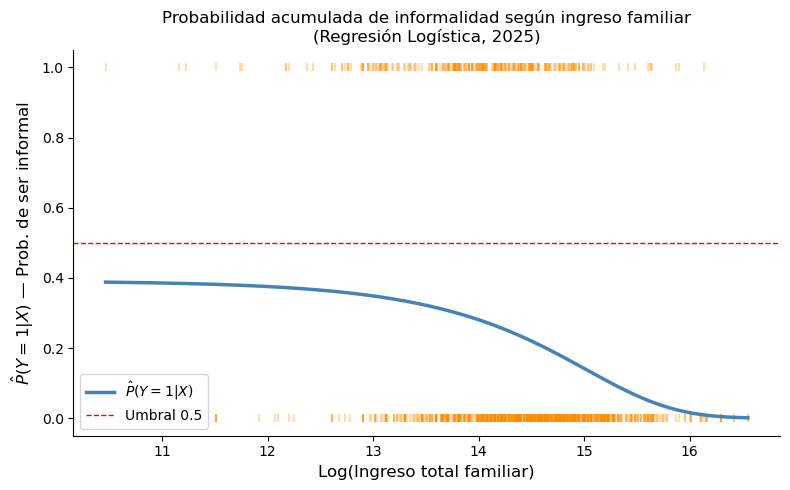

In [58]:
# B.2 corregido: ingreso en log para mostrar la sigmoide correctamente

ocupados['log_ingreso'] = np.log1p(ocupados['ingreso_total_familiar'])

# Agregar log_ingreso al X_train de 2025
X_2025_train_plot = X_2025_train.copy()
X_2025_train_plot['log_ingreso'] = np.log1p(
    df_2025_modelo.loc[X_2025_train.index, 'ingreso_total_familiar']
)

var_plot   = 'ingreso_total_familiar'
label_plot = 'Ingreso total familiar (log escala)'

log_grilla = np.linspace(
    np.log1p(X_2025_train[var_plot].min()),
    np.log1p(X_2025_train[var_plot].max()),
    300
)

# Reconstruimos la grilla sobre el X original
X_grilla = pd.DataFrame([medias_2025] * len(log_grilla), columns=X_2025_train.columns)
X_grilla[var_plot] = np.expm1(log_grilla)   # volvemos a escala original para predecir

prob_predicha = logit_2025.predict(X_grilla)

# Separamos informales/formales
mask_1 = y_2025_train == 1
mask_0 = y_2025_train == 0

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(np.log1p(X_2025_train.loc[mask_1, var_plot]), np.ones(mask_1.sum()),
           marker='|', color='darkorange', alpha=0.3, s=40)
ax.scatter(np.log1p(X_2025_train.loc[mask_0, var_plot]), np.zeros(mask_0.sum()),
           marker='|', color='darkorange', alpha=0.3, s=40)

ax.plot(log_grilla, prob_predicha, color='steelblue', linewidth=2.5,
        label='$\hat{P}(Y=1|X)$')

ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Umbral 0.5')
ax.set_xlabel('Log(Ingreso total familiar)', fontsize=12)
ax.set_ylabel('$\hat{P}(Y=1|X)$ — Prob. de ser informal', fontsize=12)
ax.set_title('Probabilidad acumulada de informalidad según ingreso familiar\n(Regresión Logística, 2025)', fontsize=12)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('logit_prob_ingreso_2025.png', dpi=300, bbox_inches='tight')
plt.show()

## C. Método de Vecinos Cercanos (KNN)

### 3. 

### 4. 

### 5. 

## D. Desempeño de modelos, elección y predicción afuera de la muestra

### 6.

### 7. 

## E. Herramientas de IA y reflexión final

Realizado en Documento de LaTeX. 